# Experiments 3.4–3.7 — The Combination Portfolio

The combination map is
$$w(\alpha)=(1-\alpha)w_{eq}+\alpha w_{sig},\qquad
w_{sig}=\frac{\Sigma^{-1}s}{\mathbf1^\top\Sigma^{-1}s}.$$
It is additive, scale-invariant but not shift-invariant, and it can short. At $\alpha=1$ it exactly reaches the map's **signal tangency-direction proxy**. Calling this exact plug-in Markowitz would additionally require $s$ to be expected excess simple returns and $\Sigma$ to be their exact covariance; those conditions are not imposed here.

Every experiment is scored by the same mean--variance CE as the softmax and Chapter 4. The ratio map remains singular at a zero normaliser, independently of the evaluator, so comparisons use an explicit domain rule and common intersection masks.


## Model and simulation design

Returns, signals, seeds and common random numbers are identical to Experiments 3.1–3.3. Performance is
$$\mathrm{CE}_{MV}(P)=\mathbb E[P]-\frac{\gamma}{2}\operatorname{Var}(P),\qquad \gamma=5,$$
reported against equal weight.

**Why CARA is not used.** Conditional on any genuine negative holding, lognormal gross returns have an unbounded right tail against the short. The positive exponential moment in CARA utility is therefore infinite, so a finite Monte-Carlo value is not a consistent estimate of a finite population CE. Mean--variance CE supplies one valid performance measure for both the long-only and shortable maps.

**Normaliser domain rule.** A setting retains draws satisfying
$$|\mathbf1^\top\Sigma^{-1}s|>0.10\,\operatorname{median}|\mathbf1^\top\Sigma^{-1}s|.$$
This conditions the estimand; it is not merely an estimator refinement. Every cross-setting comparison uses the intersection of the relevant setting-specific masks, and threshold sensitivity is reported. Within an $\alpha$ path, the return is affine in $\alpha$, making sample $\mathrm{CE}_{MV}$ exactly quadratic.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# ---------------- parameters (identical to Experiments 3.1-3.3) ----------------
N        = 20        # number of stocks
dt       = 1.0       # one step of one year
sigma    = 0.20      # diffusion volatility, common to all names (until Exp 3.6)
mu_bar   = 0.05      # cross-sectional mean of the drifts
sigma_mu = 0.05      # cross-sectional dispersion of the drifts
gamma    = 5.0       # mean--variance risk coefficient
n_sims   = 30_000    # Monte-Carlo replications

alpha_grid     = np.linspace(0.0, 2.0, 201)   # strength grid; alpha = 1 is plug-in Markowitz
alpha_grid_ext = np.linspace(0.0, 5.0, 251)   # extended grid for near-clean signals (Exp 3.5)
beta_grid      = np.linspace(0.0, 120.0, 121) # softmax grid of Experiments 3.1-3.3, for head-to-heads


# ---------------- common random numbers (identical draw order to Experiments 3.1-3.3) ----------------
mu   = mu_bar + sigma_mu * rng.standard_normal((n_sims, N))   # drifts, redrawn each replication
eps0 = rng.standard_normal((n_sims, N))                       # standardised signal noise
phi  = rng.standard_normal((n_sims, N))                       # diffusion shocks (never in the signal)

R = np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * phi) - 1.0

In [2]:
def combination_weights(s, alpha, Sigma_inv=None):
    num = s if Sigma_inv is None else s @ Sigma_inv.T
    w_sig = num / num.sum(axis=1, keepdims=True)
    return (1.0 - alpha) / N + alpha * w_sig

def softmax_weights(s, beta):
    z = beta * s
    z -= z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def ce_mv(port):
    return port.mean() - 0.5 * gamma * port.var(ddof=0)

def normaliser_mask_from_num(num, frac=0.10):
    ns = num.sum(axis=1)
    return np.abs(ns) > frac * np.median(np.abs(ns))

def valid_mask(s, Sigma_inv=None, frac=0.10):
    num = s if Sigma_inv is None else s @ Sigma_inv.T
    return normaliser_mask_from_num(num, frac)

def mv_blend_curve(p_eq, p_sig, grid):
    """Exact sample CE_MV curve for p(alpha)=p_eq+alpha*(p_sig-p_eq)."""
    d = p_sig - p_eq
    dm, p0m = d.mean(), p_eq.mean()
    cov = np.mean((p_eq - p0m) * (d - dm))
    vd = d.var(ddof=0)
    return ce_mv(p_eq) + grid * (dm - gamma * cov) - 0.5 * gamma * grid**2 * vd

def ce_sweep(s, grid, R_mat, Sigma_inv=None):
    num = s if Sigma_inv is None else s @ Sigma_inv.T
    w_sig = num / num.sum(axis=1, keepdims=True)
    p_eq, p_sig = R_mat.mean(axis=1), (w_sig * R_mat).sum(axis=1)
    CE = mv_blend_curve(p_eq, p_sig, grid)
    SHORT, LEV = np.empty(len(grid)), np.empty(len(grid))
    for k, a in enumerate(grid):
        w = (1.0-a)/N + a*w_sig
        SHORT[k] = np.abs(np.minimum(w, 0.0)).sum(axis=1).mean()
        LEV[k] = np.abs(w).sum(axis=1).mean()
    return CE, SHORT, LEV

def ce_of(w, R_mat):
    return ce_mv((w * R_mat).sum(axis=1))

def alpha_star(grid, CE):
    k = int(np.argmax(CE))
    return grid[k], CE[k], k

def best_alpha(num, R_mat, grid, mask=None):
    own = normaliser_mask_from_num(num)
    m = own if mask is None else mask
    ns = num[m].sum(axis=1)
    w_sig = num[m] / ns[:, None]
    p_eq, p_sig = R_mat[m].mean(axis=1), (w_sig * R_mat[m]).sum(axis=1)
    curve = mv_blend_curve(p_eq, p_sig, grid)
    k = int(np.argmax(curve))
    return 1e4*(curve[k]-curve[0]), grid[k], int((~own).sum())

def portfolio_from_num(num, alpha, R_mat, mask):
    ns = num[mask].sum(axis=1)
    p_eq = R_mat[mask].mean(axis=1)
    p_sig = ((num[mask]/ns[:,None]) * R_mat[mask]).sum(axis=1)
    return (1-alpha)*p_eq + alpha*p_sig

def paired_block_ce(p_a, p_b, n_blocks=6):
    vals=[]
    for ix in np.array_split(np.arange(len(p_a)), n_blocks):
        vals.append(1e4*(ce_mv(p_a[ix])-ce_mv(p_b[ix])))
    vals=np.asarray(vals)
    return vals.mean(), vals.std(ddof=1)/np.sqrt(len(vals))


## Experiment 3.4 — Strength sweep in $\alpha$

The sweep asks whether an interior optimum survives when the map may leave the simplex. Two algebraic checks anchor the path: $\alpha=1$ exactly reproduces $w_{sig}$, and near equal weight the combination and softmax paths agree to first order under the per-draw mapping $\beta=\alpha/\bar s$. The former Jensen explanation for the fixed-versus-per-draw wedge is removed: because $\bar s$ crosses zero, $\mathbb E[1/\bar s]$ does not exist, and Jensen's inequality is inapplicable.


normaliser domain rule: retained 29959 and dropped 41 of 30000
alpha=1 vs signal tangency-direction proxy: max |difference| = 0.00e+00
alpha=0.05: dCE_MV comb= 28.1 bp | per-draw softmax= 28.2 bp | fixed-beta softmax= 24.5 bp
alpha=0.1: dCE_MV comb= 55.2 bp | per-draw softmax= 55.1 bp | fixed-beta softmax= 48.4 bp


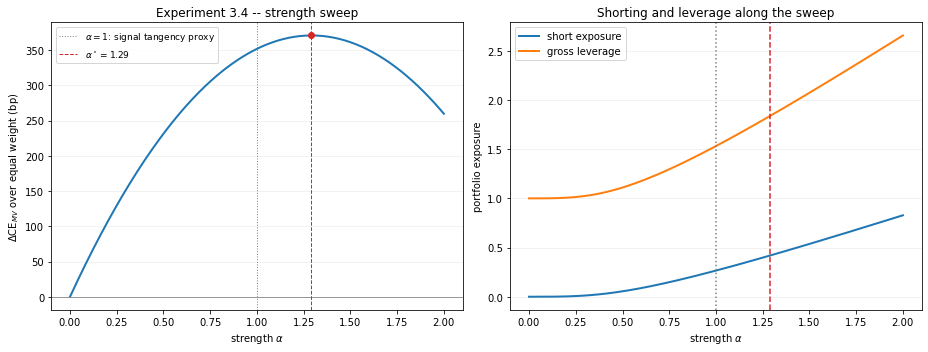


alpha*=1.29; CE_MV gain=370.9 bp; paired MC SE=9.5 bp
at alpha*: short exposure=0.42, gross leverage=1.84

normaliser-threshold sensitivity
 threshold   dropped   alpha*   peak dCE_MV
        5%        16     1.13         325.2
       10%        41     1.29         370.9
       20%       145     1.43         402.5


In [3]:
sigma_eps_base = 0.05
s_base = mu + sigma_eps_base * eps0
mask = valid_mask(s_base)
sm, Rm = s_base[mask], R[mask]
print(f"normaliser domain rule: retained {mask.sum()} and dropped {(~mask).sum()} of {n_sims}")

CE_a, SHORT_a, LEV_a = ce_sweep(sm, alpha_grid, Rm)
astar, _, k = alpha_star(alpha_grid, CE_a)
dCE_a = 1e4*(CE_a-CE_a[0])

w1 = combination_weights(sm, 1.0)
w_sig = sm/sm.sum(axis=1,keepdims=True)
print(f"alpha=1 vs signal tangency-direction proxy: max |difference| = {np.abs(w1-w_sig).max():.2e}")

sbar = sm.mean(axis=1,keepdims=True)
for a_chk in [0.05,0.10]:
    ce_c=ce_of(combination_weights(sm,a_chk),Rm)
    z=(a_chk/sbar)*sm; z-=z.max(axis=1,keepdims=True); e=np.exp(z)
    ce_sd=ce_of(e/e.sum(axis=1,keepdims=True),Rm)
    ce_fx=ce_of(softmax_weights(sm,a_chk/mu_bar),Rm)
    print(f"alpha={a_chk}: dCE_MV comb={1e4*(ce_c-CE_a[0]):5.1f} bp | per-draw softmax="
          f"{1e4*(ce_sd-CE_a[0]):5.1f} bp | fixed-beta softmax={1e4*(ce_fx-CE_a[0]):5.1f} bp")

fig,axes=plt.subplots(1,2,figsize=(13,5))
ax=axes[0]; ax.plot(alpha_grid,dCE_a,lw=2); ax.axhline(0,color='grey',lw=.8)
ax.axvline(1,color='grey',ls=':',lw=1,label=r'$\alpha=1$: signal tangency proxy')
ax.axvline(astar,color='tab:red',ls='--',lw=1,label=fr'$\alpha^\star={astar:.2f}$')
ax.scatter([astar],[dCE_a[k]],color='tab:red',zorder=5)
ax.set(xlabel=r'strength $\alpha$',ylabel=r'$\Delta$CE$_{MV}$ over equal weight (bp)',title='Experiment 3.4 -- strength sweep')
ax.grid(axis='y',alpha=.2); ax.legend(fontsize=9)
ax=axes[1]; ax.plot(alpha_grid,SHORT_a,lw=2,label='short exposure'); ax.plot(alpha_grid,LEV_a,lw=2,label='gross leverage')
ax.axvline(astar,color='tab:red',ls='--'); ax.axvline(1,color='grey',ls=':')
ax.set(xlabel=r'strength $\alpha$',ylabel='portfolio exposure',title='Shorting and leverage along the sweep')
ax.grid(axis='y',alpha=.2); ax.legend(); plt.tight_layout(); plt.show()

p0=Rm.mean(axis=1); pstar=(combination_weights(sm,astar)*Rm).sum(axis=1)
_,se_star=paired_block_ce(pstar,p0)
print(f"\nalpha*={astar:.2f}; CE_MV gain={dCE_a[k]:.1f} bp; paired MC SE={se_star:.1f} bp")
print(f"at alpha*: short exposure={SHORT_a[k]:.2f}, gross leverage={LEV_a[k]:.2f}")
print("\nnormaliser-threshold sensitivity")
print(f"{'threshold':>10}{'dropped':>10}{'alpha*':>9}{'peak dCE_MV':>14}")
for thr in [0.05,0.10,0.20]:
    mt=valid_mask(s_base,frac=thr); ce_t,_,_=ce_sweep(s_base[mt],alpha_grid,R[mt]); at,_,kt=alpha_star(alpha_grid,ce_t)
    print(f"{thr:>10.0%}{(~mt).sum():>10}{at:>9.2f}{1e4*(ce_t[kt]-ce_t[0]):>14.1f}")


**Reading.** On the stated 10% domain sample, the optimum is interior at $\alpha^\star=1.29$, with a $370.9$ bp gain and paired Monte-Carlo SE of $9.5$ bp. It has short exposure $0.42$ and gross leverage $1.84$. Performance then retreats: at $\alpha=2$ the mean return is higher, but the larger variance reduces the gain to $259.8$ bp. Thus aggressive tilting backfires under the common mean--variance criterion.

The exact magnitude is conditional on the normaliser rule. At thresholds of 5%, 10% and 20%, the peak is respectively $325.2$, $370.9$ and $402.5$ bp, with $\alpha^\star=1.13$, $1.29$ and $1.43$. The interior optimum is robust; its location and level are not threshold-free population constants.


### The optimum in P&L terms

At $\alpha^\star=1.29$, the combination portfolio beats equal weight in $77.2\%$ of paired draws and raises mean return by $745$ bp, while the 5% paired-return quantile is $-805$ bp. Because $w(\alpha)-w(0)$ is exactly linear in $\alpha$, the sign of the paired advantage is constant for every $\alpha>0$ on a retained draw; strength changes its magnitude, not which draws win.


 alpha     mean      vol  P(loss) 5%quantile  P(beat 1/N)  dCE (bp)
  0.00    5.29%    4.91%    14.0%     -2.63%           --       0.0
  1.00   11.06%   10.70%    11.2%     -3.73%        77.2%     351.9
  1.29   12.74%   13.19%    12.3%     -5.02%        77.2%     370.9
  1.50   13.95%   15.04%    12.9%     -5.98%        77.2%     361.3
  2.00   16.84%   19.56%    14.3%     -8.62%        77.2%     259.8


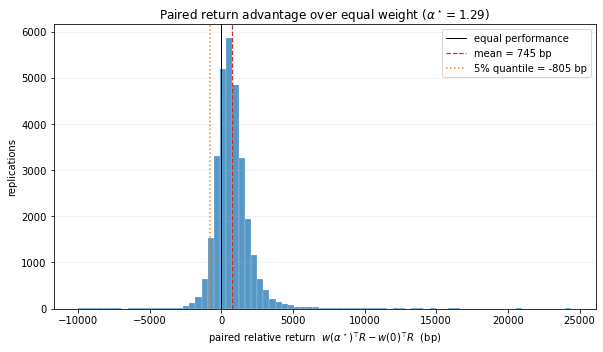

P(combination beats 1/N) = 77.2%
mean relative return = 745 bp,  5% quantile = -805 bp


In [4]:
# ---- P&L view of the CE optimum (paired against equal weight) ----
alphas_show = [0.0, 1.0, astar, 1.5, 2.0]

ports, rows = {}, []
for a in alphas_show:
    w = combination_weights(sm, a)
    p = (w * Rm).sum(axis=1)
    ports[a] = p
    ce = ce_of(w, Rm)
    rows.append((a, p.mean(), p.std(ddof=1), (p < 0).mean(),
                 np.quantile(p, 0.05),
                 (p > ports[0.0]).mean() if a > 0 else np.nan,
                 1e4 * (ce - CE_a[0])))

print(f"{'alpha':>6} {'mean':>8} {'vol':>8} {'P(loss)':>8} {'5%quantile':>10} {'P(beat 1/N)':>12} {'dCE (bp)':>9}")
for a, m, v, pl, q5, pb, dce in rows:
    pb_s = '          --' if np.isnan(pb) else f'{pb:>12.1%}'
    print(f"{a:>6.2f} {m:>8.2%} {v:>8.2%} {pl:>8.1%} {q5:>10.2%} {pb_s} {dce:>9.1f}")

d = ports[astar] - ports[0.0]
q05_d = np.quantile(d, 0.05)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.hist(1e4 * d, bins=80, color='tab:blue', alpha=0.75, edgecolor='white', linewidth=0.25)
ax.axvline(0, color='black', lw=1.0, label='equal performance')
ax.axvline(1e4 * d.mean(), color='tab:red', ls='--', lw=1.2,
           label=fr'mean = {1e4 * d.mean():.0f} bp')
ax.axvline(1e4 * q05_d, color='tab:orange', ls=':', lw=1.5,
           label=fr'5% quantile = {1e4 * q05_d:.0f} bp')
ax.set_xlabel(r'paired relative return  $w(\alpha^\star)^\top R - w(0)^\top R$  (bp)')
ax.set_ylabel('replications')
ax.set_title(fr'Paired return advantage over equal weight ($\alpha^\star = {astar:.2f}$)')
ax.grid(axis='y', alpha=0.2)
ax.legend()
plt.tight_layout(); plt.show()

print(f"P(combination beats 1/N) = {(d > 0).mean():.1%}")
print(f"mean relative return = {1e4 * d.mean():.0f} bp,  5% quantile = {1e4 * q05_d:.0f} bp")

### Shift-invariance: a structural difference

The softmax satisfies $\operatorname{softmax}(\beta(\boldsymbol{s} + c\mathbf{1})) = \operatorname{softmax}(\beta\boldsymbol{s})$ for any constant $c$: only cross-sectional *differences* in the signal matter, never its level. The combination map does not — $c$ enters the normaliser $\mathbf{1}^\top\boldsymbol{s} + Nc$, so shifting all views up makes $\boldsymbol{w}_{\mathrm{sig}}$ *less* aggressive (deviations are divided by a larger total) and shifting them down makes it more aggressive. The check below verifies the softmax invariance to machine precision and traces the combination sweep for shifted signals $\boldsymbol{s} + c\mathbf{1}$.

The extreme case is instructive: **fully demeaning the signal** ($c = -\bar\mu$) centres the normaliser on zero, so $\boldsymbol{w}_{\mathrm{sig}}$ explodes or flips sign on roughly half the draws and the map is effectively undefined. What the softmax treats as a harmless reparametrisation is, for the combination portfolio, the difference between a working allocation rule and a meaningless one. This is the concrete sense in which the signal *level* $\bar\mu$ — irrelevant throughout Experiments 3.1–3.3 — becomes load-bearing the moment the map leaves the simplex.

softmax under shifts: max |weight difference| = 5.55e-16


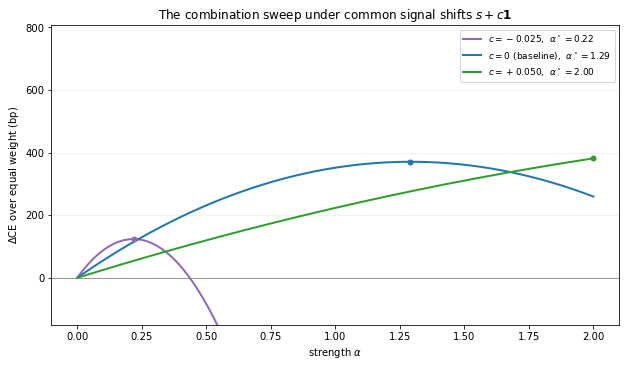

demeaned signal (c = -mu_bar): normaliser negative on 50.0% of draws (the tangency leg flips direction on a coin flip); guard would drop 5.4% — the map stops being usable


In [5]:
# ---- shift-invariance check ----
c_shifts = [-0.025, 0.0, +0.05]

# softmax: weights identical under any common shift (to machine precision)
w_ref = softmax_weights(sm, 21.0)
max_dev = max(np.abs(softmax_weights(sm + c, 21.0) - w_ref).max() for c in c_shifts if c != 0)
print(f"softmax under shifts: max |weight difference| = {max_dev:.2e}")

# combination: the sweep itself moves
fig, ax = plt.subplots(figsize=(8.8, 5.2))
for c, col in zip(c_shifts, ['tab:purple', 'tab:blue', 'tab:green']):
    s_c    = s_base + c
    mask_c = valid_mask(s_c)
    CE_c, _, _ = ce_sweep(s_c[mask_c], alpha_grid, R[mask_c])
    a_c, _, k_c = alpha_star(alpha_grid, CE_c)
    lbl = (r'$c=0$ (baseline)' if c == 0 else fr'$c={c:+.3f}$') + fr',  $\alpha^\star={a_c:.2f}$'
    ax.plot(alpha_grid, 1e4 * (CE_c - CE_c[0]), lw=2, color=col, label=lbl)
    ax.scatter([a_c], [1e4 * (CE_c[k_c] - CE_c[0])], color=col, zorder=5, s=25)
ax.axhline(0, color='grey', lw=0.8)
ax.set_xlabel(r'strength $\alpha$')
ax.set_ylabel(r'$\Delta$CE over equal weight (bp)')
ax.set_title(r'The combination sweep under common signal shifts $s + c\mathbf{1}$')
ax.set_ylim(-150, None)
ax.grid(axis='y', alpha=0.2)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

# the demeaned extreme: shift by c = -mu_bar so the normaliser is centred on zero
s_dm = s_base - mu_bar
ns_dm = s_dm.sum(axis=1)
print(f"demeaned signal (c = -mu_bar): normaliser negative on {(ns_dm < 0).mean():.1%} of draws "
      f"(the tangency leg flips direction on a coin flip); guard would drop "
      f"{(~valid_mask(s_dm)).mean():.1%} — the map stops being usable")

**Reading.** Softmax remains exactly shift-invariant, whereas a common score shift changes the combination normaliser and therefore the entire path. The per-draw first-order correspondence remains a useful local check, but the fixed-$\beta$ wedge should be reported numerically rather than attributed to Jensen. Demeaning is not a repair for the ratio map: it centres the normaliser on zero and reverses the tangency direction in roughly half the draws.


## Experiment 3.5 — Signal quality

Signal-noise levels are compared on one common intersection sample, retained across the whole ladder. The Gaussian reliability factor
$$\kappa=\frac{\sigma_\mu^2}{\sigma_\mu^2+\sigma_\varepsilon^2}$$
provides an approximate benchmark $\alpha^\star_{clean}\kappa$. Unlike softmax, posterior shrinkage changes the random normaliser as well as cross-sectional dispersion, so the benchmark is not exact. The strength grid is $[0,5]$.


common comparison sample: retained 27809, dropped 2191


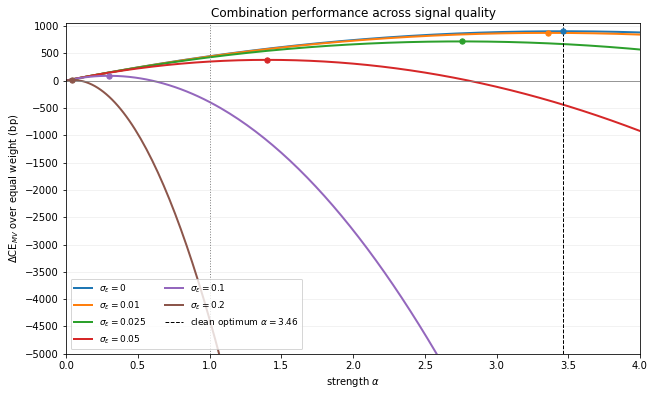

 sigma_eps   alpha*  kappa pred   peak dCE_MV  own drops    MC SE
       0.0     3.46        3.46         902.5          0     25.1
      0.01     3.36        3.33         872.8          0     24.8
     0.025     2.76        2.77         716.6          1     18.0
      0.05     1.40        1.73         379.2         41     12.4
       0.1     0.30        0.69          87.2        649      3.5
       0.2     0.04        0.20          10.8       1503      0.6


In [6]:
# ---- signal-quality sweep on one common intersection sample ----
sigma_eps_levels=[0.0,0.01,0.025,0.05,0.10,0.20]
signals35={se:mu+se*eps0 for se in sigma_eps_levels}
masks35={se:valid_mask(s) for se,s in signals35.items()}
common35=np.logical_and.reduce(list(masks35.values()))
print(f"common comparison sample: retained {common35.sum()}, dropped {(~common35).sum()}")
results35={}
for se,s_l in signals35.items():
    ce_l,_,_=ce_sweep(s_l[common35],alpha_grid_ext,R[common35])
    results35[se]=(ce_l,int((~masks35[se]).sum()))

astars35=np.array([alpha_star(alpha_grid_ext,results35[se][0])[0] for se in sigma_eps_levels])
kappa=sigma_mu**2/(sigma_mu**2+np.array(sigma_eps_levels)**2); pred=astars35[0]*kappa

# Report figure: retain the full strength grid but zoom the displayed CE range.
# Values outside the y-axis limits are still used in every calculation.
fig,ax=plt.subplots(figsize=(9.2,5.6))
for se in sigma_eps_levels:
    ce_l,_=results35[se]
    dce=1e4*(ce_l-ce_l[0])
    line,=ax.plot(alpha_grid_ext,dce,lw=2,label=fr'$\sigma_\varepsilon={se:g}$')
    kk=int(np.argmax(dce))
    ax.scatter(alpha_grid_ext[kk],dce[kk],s=28,color=line.get_color(),zorder=4)
ax.axhline(0,color='grey',lw=.8)
ax.axvline(1,color='grey',ls=':',lw=1)
ax.axvline(astars35[0],color='black',ls='--',lw=1,label=fr'clean optimum $\alpha={astars35[0]:.2f}$')
ax.set_xlim(0,4); ax.set_ylim(-5000,1050)
ax.set_yticks(np.arange(-5000,1001,500))
ax.set(xlabel=r'strength $\alpha$',ylabel=r'$\Delta$CE$_{MV}$ over equal weight (bp)',title='Combination performance across signal quality')
ax.grid(axis='y',alpha=.2); ax.legend(fontsize=9,ncol=2,loc='lower left')
plt.tight_layout()
plt.savefig('experiment5_signal_quality_report.png',dpi=300,bbox_inches='tight')
plt.show()

print(f"{'sigma_eps':>10}{'alpha*':>9}{'kappa pred':>12}{'peak dCE_MV':>14}{'own drops':>11}{'MC SE':>9}")
for se,a_s,pr in zip(sigma_eps_levels,astars35,pred):
    ce_l,drop=results35[se]; _,_,kk=alpha_star(alpha_grid_ext,ce_l)
    num=signals35[se]; pa=portfolio_from_num(num,a_s,R,common35); p0=R[common35].mean(axis=1)
    _,se_mc=paired_block_ce(pa,p0)
    print(f"{se:>10}{a_s:>9.2f}{pr:>12.2f}{1e4*(ce_l[kk]-ce_l[0]):>14.1f}{drop:>11}{se_mc:>9.1f}")


**Reading.** On the common sample, $\alpha^\star$ retreats $3.46\to3.36\to2.76\to1.40\to0.30\to0.04$ as noise increases, while the peak gain falls $902.5\to872.8\to716.6\to379.2\to87.2\to10.8$ bp. The retreat is close to the $\kappa$ benchmark at low noise and faster at high noise, consistent with the extra leverage/normaliser channel of the ratio map.

There are no CARA stability-truncated lower bounds after the estimator change. Monte-Carlo SEs range from $25.1$ bp at the clean optimum to $0.6$ bp at the noisiest optimum. Results remain conditional on the common domain sample, which drops 2,191 of 30,000 draws.


### Normaliser-domain sensitivity

The former maximum-single-draw-share diagnostic is removed because it could not make the CARA population objective finite. The controlled diagnostic now varies the normaliser threshold. At higher signal noise, both the retained sample and the headline optimum move materially; these results must therefore be described as conditional on the stated rule rather than as an unconditional population effect.


In [7]:
# ---- sensitivity of the conditional estimand to the normaliser threshold ----
print("normaliser-threshold sensitivity by signal-noise level (setting-specific samples)")
print(f"{'threshold':>10}{'sigma_eps':>12}{'dropped':>10}{'alpha*':>9}{'peak dCE_MV':>14}")
for thr in [0.05,0.10,0.20]:
    for se in [0.05,0.10,0.20]:
        s_l=signals35[se]; m=valid_mask(s_l,frac=thr)
        ce_l,_,_=ce_sweep(s_l[m],alpha_grid_ext,R[m]); a,_,kk=alpha_star(alpha_grid_ext,ce_l)
        print(f"{thr:>10.0%}{se:>12.2f}{(~m).sum():>10}{a:>9.2f}{1e4*(ce_l[kk]-ce_l[0]):>14.1f}")


normaliser-threshold sensitivity by signal-noise level (setting-specific samples)
 threshold   sigma_eps   dropped   alpha*   peak dCE_MV
        5%        0.05        16     1.12         325.2
        5%        0.10       314     0.16          51.2
        5%        0.20       756     0.02           4.6
       10%        0.05        41     1.30         370.9
       10%        0.10       649     0.30          93.7
       10%        0.20      1503     0.04           9.5
       20%        0.05       145     1.42         402.5
       20%        0.10      1347     0.46         133.2
       20%        0.20      2944     0.08          16.8


**Reading.** Across 5%, 10% and 20% thresholds, the baseline-noise peak ranges from $325$ to $403$ bp; at $\sigma_\varepsilon=0.10$ it ranges from $51$ to $133$ bp, and at $0.20$ from $5$ to $17$ bp. The qualitative retreat with noise survives, but precise basis-point levels and optimal strengths depend on which near-pole draws the domain definition excludes.


## Experiment 3.6 — Drift and volatility input error

Volatilities are heterogeneous and a multiplicative signal is observed,
$$\hat\sigma_i=\sigma_i\exp(\nu\eta_i-\nu^2/2).$$
The correction makes $\hat\sigma_i$ **mean-unbiased**, not median-unbiased. The linear variance shrinkage used below is indexed by reliability on the log-volatility scale, but it is not the Bayesian posterior mean of $\sigma_i^2$: the prior is clipped-normal and therefore log volatility is not Gaussian. It is described as reliability-motivated shrinkage.


### Part (i) — matched information indices

Drift noise is absolute while volatility noise is relative. Both are indexed by
$$r=\frac{\text{cross-sectional signal dispersion}^2}{\text{dispersion}^2+\text{noise}^2},$$
using $\sigma_\mu$ for drift and $d=\operatorname{sd}(\log\sigma_i)$ for volatility. Because the volatility prior is not log-Gaussian, $r$ is an information-matching index rather than an exact posterior weight. All ten channel-by-rung settings use one common intersection sample, and $\alpha$ is re-optimised in every setting.


part (i) common sample: retained 26148, dropped 3852


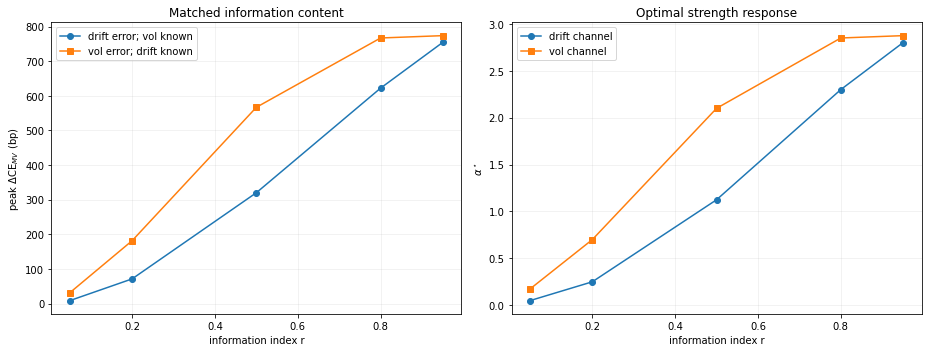

     r|  drift dCE  alpha*|   vol dCE  alpha*|  vol-drift  paired SE
  0.95|      754.2    2.80|     773.7    2.88|       19.5       26.8
  0.80|      622.1    2.30|     766.9    2.85|      144.8       21.3
  0.50|      319.9    1.12|     566.7    2.10|      246.9       14.0
  0.20|       71.1    0.25|     181.3    0.70|      110.3       15.2
  0.05|        8.5    0.05|      31.4    0.18|       22.9        4.5
log-vol dispersion index d=0.2744; clipped-normal prior means r is an information-matching index, not an exact posterior weight


In [8]:
# ---- Experiment 3.6: heterogeneous volatility and matched information ----
rng_vol=np.random.default_rng(4343)
sigma_bar,sigma_sig=0.20,0.05
sig_i=np.clip(sigma_bar+sigma_sig*rng_vol.standard_normal((n_sims,N)),0.05,None)
eta0=rng_vol.standard_normal((n_sims,N))
R_het=np.exp((mu-.5*sig_i**2)*dt+sig_i*np.sqrt(dt)*phi)-1
var_bar=np.mean(sig_i**2)  # exact simulated prior mean after clipping
d_logvol=np.log(sig_i).std()
s36=mu+sigma_eps_base*eps0
alpha_g36=np.linspace(0,8,321)

r_levels=[.95,.8,.5,.2,.05]
nums_drift={}; nums_vol={}
for r in r_levels:
    fac=np.sqrt((1-r)/r)
    nums_drift[r]=(mu+sigma_mu*fac*eps0)/sig_i**2
    nu=d_logvol*fac
    sh=sig_i*np.exp(nu*eta0-.5*nu**2)
    nums_vol[r]=mu/sh**2
all_masks=[normaliser_mask_from_num(x) for x in list(nums_drift.values())+list(nums_vol.values())]
common36_i=np.logical_and.reduce(all_masks)
print(f"part (i) common sample: retained {common36_i.sum()}, dropped {(~common36_i).sum()}")
rows_drift=[best_alpha(nums_drift[r],R_het,alpha_g36,common36_i) for r in r_levels]
rows_vol=[best_alpha(nums_vol[r],R_het,alpha_g36,common36_i) for r in r_levels]

fig,axes=plt.subplots(1,2,figsize=(13,5)); ax=axes[0]
ax.plot(r_levels,[x[0] for x in rows_drift],'o-',label='drift error; vol known')
ax.plot(r_levels,[x[0] for x in rows_vol],'s-',label='vol error; drift known')
ax.set(xlabel='information index r',ylabel=r'peak $\Delta$CE$_{MV}$ (bp)',title='Matched information content')
ax.grid(alpha=.2); ax.legend(); ax=axes[1]
ax.plot(r_levels,[x[1] for x in rows_drift],'o-',label='drift channel')
ax.plot(r_levels,[x[1] for x in rows_vol],'s-',label='vol channel')
ax.set(xlabel='information index r',ylabel=r'$\alpha^\star$',title='Optimal strength response')
ax.grid(alpha=.2); ax.legend(); plt.tight_layout(); plt.show()

print(f"{'r':>6}|{'drift dCE':>11}{'alpha*':>8}|{'vol dCE':>10}{'alpha*':>8}|{'vol-drift':>11}{'paired SE':>11}")
for r,a,b in zip(r_levels,rows_drift,rows_vol):
    pd=portfolio_from_num(nums_drift[r],a[1],R_het,common36_i)
    pv=portfolio_from_num(nums_vol[r],b[1],R_het,common36_i)
    gap,se=paired_block_ce(pv,pd)
    print(f"{r:>6.2f}|{a[0]:>11.1f}{a[1]:>8.2f}|{b[0]:>10.1f}{b[1]:>8.2f}|{gap:>11.1f}{se:>11.1f}")
print(f"log-vol dispersion index d={d_logvol:.4f}; clipped-normal prior means r is an information-matching index, not an exact posterior weight")


**Reading.** Both channels retreat as information is lost. The volatility-error curve lies above the drift-error curve at every rung: with the other input held clean, degrading drift is more costly than degrading volatility. The paired gaps are $19.5$, $144.8$, $246.9$, $110.3$ and $22.9$ bp from $r=0.95$ to $0.05$; all except the first are large relative to their paired Monte-Carlo SEs. The $r=0.95$ difference is not resolved ($19.5$ bp, SE $26.8$), so the evidence supports the ordering over the middle and low-information rungs, not a universal strict inequality at every calibration.

The common intersection drops 3,852 draws, making these values explicitly conditional. The result supports the literature's qualitative first-moment-versus-second-moment asymmetry without claiming that the numerical ratio is universal.


### Part (ii) — reliability-motivated shrinkage

The design is a $2\times3$ factorial: drift is raw or shrunk, crossed with volatility ignored, raw or shrunk. The six configurations use one common intersection sample and re-optimise $\alpha$. Paired block standard errors are reported for the three substantive contrasts.


part (ii) common sample: retained 29646, dropped 354
kappa_mu=0.50; reliability-motivated kappa_sigma=0.65

                                   vol IGNORED               vol RAW            vol SHRUNK
               drift RAW         370 bp a=1.30          242 bp a=0.80          409 bp a=1.40 
            drift SHRUNK         474 bp a=3.73          348 bp a=2.50          480 bp a=3.58 

paired contrasts
shrink drift, vol raw                         +106.2 bp  (paired SE 10.1)
shrink vol, drift raw                         +167.2 bp  (paired SE 10.0)
use best vol, drift shrunk                      +6.3 bp  (paired SE 4.7)


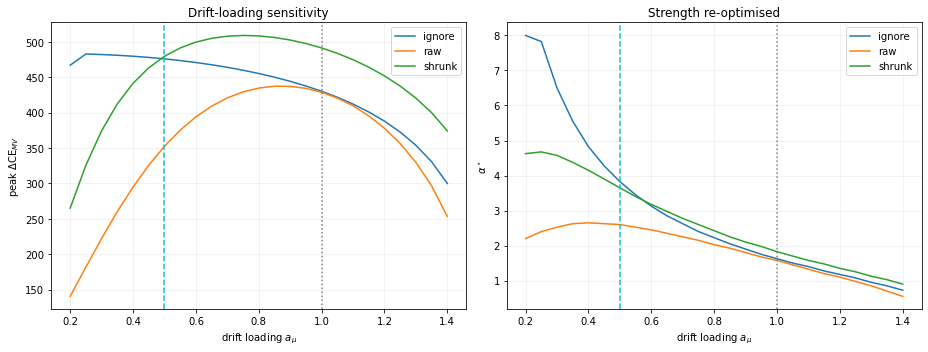

In [9]:
# ---- part (ii): 2x3 factorial on a common intersection sample ----
nu_36=.20
sighat=sig_i*np.exp(nu_36*eta0-.5*nu_36**2)
kappa_mu=sigma_mu**2/(sigma_mu**2+sigma_eps_base**2)
kappa_vol=d_logvol**2/(d_logvol**2+nu_36**2)
vol_levels=[('ignore',0.0),('raw',1.0),('shrunk',kappa_vol)]
drift_levels=[('raw',1.0),('shrunk',kappa_mu)]
nums36={(lm,lv):(mu_bar+am*(s36-mu_bar))/(var_bar+av*(sighat**2-var_bar))
        for lm,am in drift_levels for lv,av in vol_levels}
common36_ii=np.logical_and.reduce([normaliser_mask_from_num(x) for x in nums36.values()])
cells={key:best_alpha(num,R_het,alpha_g36,common36_ii) for key,num in nums36.items()}
print(f"part (ii) common sample: retained {common36_ii.sum()}, dropped {(~common36_ii).sum()}")
print(f"kappa_mu={kappa_mu:.2f}; reliability-motivated kappa_sigma={kappa_vol:.2f}\n")
print(f"{'':>24}{'vol IGNORED':>22}{'vol RAW':>22}{'vol SHRUNK':>22}")
for lm,_ in drift_levels:
    lab='drift RAW' if lm=='raw' else 'drift SHRUNK'
    rr=[cells[(lm,lv)] for lv,_ in vol_levels]
    print(f"{lab:>24}"+''.join(f"{x[0]:>12.0f} bp a={x[1]:<5.2f}" for x in rr))

def report_pair(label,key_a,key_b):
    a,b=cells[key_a],cells[key_b]
    pa=portfolio_from_num(nums36[key_a],a[1],R_het,common36_ii)
    pb=portfolio_from_num(nums36[key_b],b[1],R_het,common36_ii)
    gap,se=paired_block_ce(pa,pb)
    print(f"{label:<44}{gap:+8.1f} bp  (paired SE {se:.1f})")
print("\npaired contrasts")
report_pair('shrink drift, vol raw',('shrunk','raw'),('raw','raw'))
report_pair('shrink vol, drift raw',('raw','shrunk'),('raw','raw'))
report_pair('use best vol, drift shrunk',('shrunk','shrunk'),('shrunk','ignore'))

amu_g=np.linspace(.2,1.4,25)
curve_nums={(am,lv):(mu_bar+am*(s36-mu_bar))/(var_bar+av*(sighat**2-var_bar)) for am in amu_g for lv,av in vol_levels}
common_curve=np.logical_and.reduce([normaliser_mask_from_num(x) for x in curve_nums.values()])
curves={lv:[best_alpha(curve_nums[(am,lv)],R_het,alpha_g36,common_curve) for am in amu_g] for lv,_ in vol_levels}
fig,axes=plt.subplots(1,2,figsize=(13,5)); ax=axes[0]
for lv,rows in curves.items(): ax.plot(amu_g,[x[0] for x in rows],label=lv)
ax.axvline(kappa_mu,color='tab:cyan',ls='--'); ax.axvline(1,color='grey',ls=':')
ax.set(xlabel=r'drift loading $a_\mu$',ylabel=r'peak $\Delta$CE$_{MV}$',title='Drift-loading sensitivity'); ax.grid(alpha=.2); ax.legend()
ax=axes[1]
for lv,rows in curves.items(): ax.plot(amu_g,[x[1] for x in rows],label=lv)
ax.axvline(kappa_mu,color='tab:cyan',ls='--'); ax.axvline(1,color='grey',ls=':')
ax.set(xlabel=r'drift loading $a_\mu$',ylabel=r'$\alpha^\star$',title='Strength re-optimised'); ax.grid(alpha=.2); ax.legend()
plt.tight_layout(); plt.show()


**Reading.** On the common sample, the six peak gains are:

| | vol ignored | vol raw | vol shrunk |
|---|---:|---:|---:|
| drift raw | 370 bp | 242 bp | 409 bp |
| drift shrunk | 474 bp | 348 bp | 480 bp |

Shrinking drift with raw volatility adds $106.2$ bp (paired SE $10.1$); shrinking volatility with raw drift adds $167.2$ bp (SE $10.0$). These are well resolved. With drift already shrunk, the best volatility treatment adds only $6.3$ bp over ignoring volatility (SE $4.7$), so this small incremental value is not statistically resolved by the present simulation. The safe conclusion is that raw noisy volatility is harmful and shrinkage repairs much of that damage; the experiment does not establish a material independent volatility-signal benefit once drift is handled well.


### Part (iii) — weak identification of individual loadings

Global strength and per-signal loadings all influence distance from equal weight and can compensate for one another. The resulting ridge tests whether the present calibration distinguishes their individual contributions. This is not assumed to be exact structural non-identification: random normalisers and nonlinear variance scaling prevent an exact general redundancy.


In [10]:
# ---- part (iii): three-parameter ridge on one common sample ----
amu_g3,avol_g3=np.linspace(.30,1.10,9),np.linspace(0,1,11)
nums_grid={(round(am,2),round(av,2)):(mu_bar+am*(s36-mu_bar))/(var_bar+av*(sighat**2-var_bar)) for am in amu_g3 for av in avol_g3}
common36_iii=np.logical_and.reduce([normaliser_mask_from_num(x) for x in nums_grid.values()])
grid3={key:best_alpha(num,R_het,alpha_g36,common36_iii)[:2] for key,num in nums_grid.items()}
(g_am,g_av),(g_d,g_al)=max(grid3.items(),key=lambda kv:kv[1][0])
print(f"common sample retained {common36_iii.sum()}, dropped {(~common36_iii).sum()}")
print(f"three-parameter optimum: a_mu={g_am:.2f}, a_sigma={g_av:.2f}, alpha={g_al:.2f}, dCE_MV={g_d:.1f} bp")

def theta_deficit(w):
    wt=np.abs(w); wt/=wt.sum(axis=1,keepdims=True)
    with np.errstate(divide='ignore',invalid='ignore'): H=-np.where(wt>0,wt*np.log(wt),0).sum(axis=1)
    return 1-H/np.log(N)
def portfolio36(am,av,al):
    num=nums_grid[(round(am,2),round(av,2))]; ns=num[common36_iii].sum(axis=1)
    w=(1-al)/N+al*num[common36_iii]/ns[:,None]
    return w,np.abs(w).sum(axis=1).mean(),theta_deficit(w).mean()

print(f"{'a_mu':>6}{'a_sigma*':>10}{'alpha*':>9}{'dCE_MV':>11}{'leverage':>10}{'theta':>8}")
ridge=[]
for am in amu_g3[:4]:
    sub={kk:v for kk,v in grid3.items() if kk[0]==round(am,2)}; key=max(sub,key=lambda kk:sub[kk][0]); d,a=sub[key]
    w,lev,th=portfolio36(am,key[1],a); ridge.append((am,key[1],a,w))
    print(f"{am:>6.2f}{key[1]:>10.2f}{a:>9.2f}{d:>11.1f}{lev:>10.2f}{th:>8.3f}")
w1,w2=ridge[0][3],ridge[-1][3]
print(f"weight correlation across ridge endpoints: {np.corrcoef(w1.ravel(),w2.ravel())[0,1]:.4f}")
print(f"mean |weight difference|: {np.abs(w1-w2).mean():.4f} (equal weight={1/N:.3f})")


common sample retained 29238, dropped 762
three-parameter optimum: a_mu=0.50, a_sigma=0.30, alpha=3.95, dCE_MV=513.5 bp
  a_mu  a_sigma*   alpha*     dCE_MV  leverage   theta
  0.30      0.10     6.65      505.9      2.36   0.093
  0.40      0.20     4.98      511.5      2.38   0.095
  0.50      0.30     3.95      513.5      2.39   0.098
  0.60      0.40     3.25      512.3      2.38   0.102
weight correlation across ridge endpoints: 0.9782
mean |weight difference|: 0.0213 (equal weight=0.050)


**Reading.** The optimum lies on a shallow ridge. Moving from $(a_\mu,a_\sigma)=(0.30,0.10)$ to $(0.60,0.40)$ changes peak $\Delta\mathrm{CE}_{MV}$ from $505.9$ to $512.3$ bp while $\alpha$ falls $6.65\to3.25$. Endpoint weight correlation is $0.9782$, but mean absolute weight difference is $0.0213$ against equal weight $0.05$. The parameters are therefore **weakly identified under this calibration**, not structurally unidentified. The portfolio-level conclusion is more stable than attribution to a particular loading.


## Experiment 3.7 — Correlated assets under common and heterogeneous volatility

The experiment has two parts. Part (i) restores the common-volatility design of Experiment 3.3, so correlation is the only change and the two maps can be compared directly. Part (ii) repeats the same head-to-head with heterogeneous volatilities redrawn by replication using the clipped-normal design of Experiment 3.6. In both parts, softmax uses only the drift signal and the combination map receives the true covariance matrix; no covariance estimator or volatility signal is fitted.

In Part (ii), for an equicorrelation matrix $C(\rho)$, the return covariance in replication $r$ is
$$\Sigma_r=\operatorname{diag}(\sigma_r)C(\rho)\operatorname{diag}(\sigma_r).$$
Unlike the common-volatility case, changing $\rho$ can now change the combination portfolio's direction rather than merely rescaling its strength coordinate, because the diagonal volatility matrix does not generally commute with $C(\rho)$. The common-shock exposure is $\sum_i w_i\sigma_i$, which is not fixed by the budget constraint $\sum_iw_i=1$.


In [11]:
# ---- Experiment 3.7(i): common volatility and correlated assets ----
rho_levels=[0.0,.25,.5]; rng_corr=np.random.default_rng(4242); z0=rng_corr.standard_normal((n_sims,1))
k_fac=3; rng_fac=np.random.default_rng(7); B=np.empty((N,k_fac)); B[:,0]=.45+.15*rng_fac.standard_normal(N); B[:,1:]=.30*rng_fac.standard_normal((N,k_fac-1))
norms=np.sqrt((B**2).sum(axis=1)); too_big=norms>.95; B[too_big]*=(.95/norms[too_big])[:,None]
idio=np.sqrt(1-(B**2).sum(axis=1)); F=rng_fac.standard_normal((n_sims,k_fac))
cases_hom={}
for rho in rho_levels:
    C=(1-rho)*np.eye(N)+rho*np.ones((N,N)); ph=np.sqrt(rho)*z0+np.sqrt(1-rho)*phi
    cases_hom[fr'equicorr $\rho={rho}$']=(C,ph)
C_fac=B@B.T+np.diag(idio**2); cases_hom['factor model']=(C_fac,F@B.T+phi*idio)
case_data_hom={}
for name,(C,ph) in cases_hom.items():
    Sinv=np.linalg.inv(sigma**2*C*dt); num=s_base@Sinv.T
    Rc=np.exp((mu-.5*sigma**2)*dt+sigma*np.sqrt(dt)*ph)-1
    case_data_hom[name]=(Sinv,num,Rc,normaliser_mask_from_num(num))
common37_hom=np.logical_and.reduce([x[3] for x in case_data_hom.values()])
print(f'Part (i), common volatility: retained {common37_hom.sum()}, dropped {(~common37_hom).sum()}')
print(f"{'case':>22}{'a*':>7}{'comb peak':>12}{'b*':>6}{'sfmx peak':>12}{'gap':>9}{'gap SE':>9}{'own drops':>11}{'gross p99':>10}{'short p99':>10}")
summary37_hom={}
for name,(Sinv,num,Rc,ownmask) in case_data_hom.items():
    sc=s_base[common37_hom]; rcm=Rc[common37_hom]
    ce_c,_,_=ce_sweep(sc,alpha_grid,rcm,Sinv); a,_,kc=alpha_star(alpha_grid,ce_c)
    ce_s=np.array([ce_of(softmax_weights(sc,b),rcm) for b in beta_grid]); ks=int(np.argmax(ce_s))
    cp=1e4*(ce_c[kc]-ce_c[0]); sp=1e4*(ce_s[ks]-ce_s[0])
    wsig=num[common37_hom]/num[common37_hom].sum(axis=1,keepdims=True); wheld=(1-a)/N+a*wsig
    p_comb=(wheld*rcm).sum(axis=1); p_soft=(softmax_weights(sc,beta_grid[ks])*rcm).sum(axis=1)
    _,gap_se=paired_block_ce(p_comb,p_soft)
    held_g99=np.quantile(np.abs(wheld).sum(axis=1),.99); held_s99=np.quantile(np.maximum(-wheld,0).sum(axis=1),.99)
    summary37_hom[name]=(cp,sp,a,beta_grid[ks]); clean=name.replace('$','').replace('\\rho','rho')
    print(f"{clean:>22}{a:>7.2f}{cp:>12.1f}{beta_grid[ks]:>6.0f}{sp:>12.1f}{cp-sp:>9.1f}{gap_se:>9.1f}{(~ownmask).sum():>11}{held_g99:>10.2f}{held_s99:>10.2f}")



Part (i), common volatility: retained 29557, dropped 443
                  case     a*   comb peak    b*   sfmx peak      gap   gap SE  own drops gross p99 short p99
      equicorr rho=0.0   1.37       387.5    18       266.1    121.4      4.0         41      5.09      2.04
     equicorr rho=0.25   0.21       440.1    21       283.8    156.3      8.8         41      5.97      2.48
      equicorr rho=0.5   0.10       526.7    26       312.3    214.3     15.5         41      7.74      3.37
          factor model   0.19       267.0    20       273.1     -6.1     10.2        411      6.52      2.76


Part (ii), heterogeneous volatility: retained 26565, dropped 3435
                  case     a*   comb peak    b*   sfmx peak      gap   gap SE  own drops gross p99 short p99
      equicorr rho=0.0   0.95       269.9    18       255.9     14.1      7.8        231      6.17      2.59
     equicorr rho=0.25   0.11       125.4    20       275.8   -150.4     12.0       1102      4.84      1.92
      equicorr rho=0.5   0.07       129.2    25       304.1   -175.0     16.4       1545      5.00      2.00
          factor model   0.18       170.4    19       264.1    -93.8     11.9        989      5.78      2.39


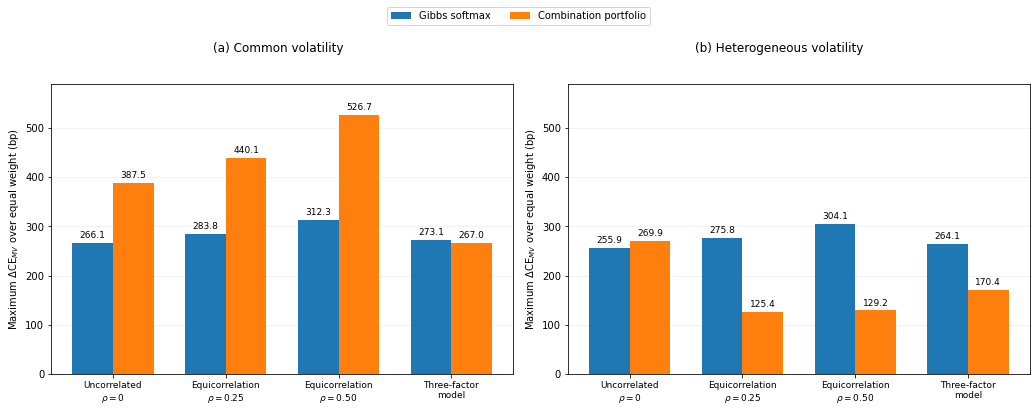


normaliser-threshold sensitivity: combination-minus-softmax gap (bp)
 threshold  retained      equicorr rho=0.0     equicorr rho=0.25      equicorr rho=0.5          factor model
        5%     28174                 -78.7                -203.4                -250.5                -166.9
       10%     26565                  14.1                -150.4                -175.0                 -93.8
       20%     24085                 120.0                  12.7                  44.6                  47.8


In [12]:
# ---- Experiment 3.7(ii): heterogeneous volatility and correlated assets ----
rho_levels=[0.0,.25,.5]; rng_corr=np.random.default_rng(4242); z0=rng_corr.standard_normal((n_sims,1))
k_fac=3; rng_fac=np.random.default_rng(7); B=np.empty((N,k_fac)); B[:,0]=.45+.15*rng_fac.standard_normal(N); B[:,1:]=.30*rng_fac.standard_normal((N,k_fac-1))
norms=np.sqrt((B**2).sum(axis=1)); too_big=norms>.95; B[too_big]*=(.95/norms[too_big])[:,None]
idio=np.sqrt(1-(B**2).sum(axis=1)); F=rng_fac.standard_normal((n_sims,k_fac))
cases={}
for rho in rho_levels:
    C=(1-rho)*np.eye(N)+rho*np.ones((N,N)); ph=np.sqrt(rho)*z0+np.sqrt(1-rho)*phi
    cases[fr'equicorr $\rho={rho}$']=(C,ph)
C_fac=B@B.T+np.diag(idio**2); cases['factor model']=(C_fac,F@B.T+phi*idio)
case_data={}
for name,(C,ph) in cases.items():
    Cinv=np.linalg.inv(C)
    # Sigma_r^{-1}s_r = D_r^{-1} C^{-1} D_r^{-1}s_r / dt, with D_r=diag(sigma_r).
    num=((s_base/sig_i)@Cinv.T)/sig_i/dt
    Rc=np.exp((mu-.5*sig_i**2)*dt+sig_i*np.sqrt(dt)*ph)-1
    case_data[name]=(C,Cinv,num,Rc,normaliser_mask_from_num(num))
common37=np.logical_and.reduce([x[4] for x in case_data.values()])
print(f"Part (ii), heterogeneous volatility: retained {common37.sum()}, dropped {(~common37).sum()}")
print(f"{'case':>22}{'a*':>7}{'comb peak':>12}{'b*':>6}{'sfmx peak':>12}{'gap':>9}{'gap SE':>9}{'own drops':>11}{'gross p99':>10}{'short p99':>10}")
summary={}
for name,(C,Cinv,num,Rc,ownmask) in case_data.items():
    sc=s_base[common37]; rcm=Rc[common37]
    wsig=num[common37]/num[common37].sum(axis=1,keepdims=True)
    p_eq=rcm.mean(axis=1); p_sig=(wsig*rcm).sum(axis=1)
    ce_c=mv_blend_curve(p_eq,p_sig,alpha_grid); a,_,kc=alpha_star(alpha_grid,ce_c)
    ce_s=np.array([ce_of(softmax_weights(sc,b),rcm) for b in beta_grid]); ks=int(np.argmax(ce_s))
    cp=1e4*(ce_c[kc]-ce_c[0]); sp=1e4*(ce_s[ks]-ce_s[0])
    p_comb=(1-a)*p_eq+a*p_sig
    p_soft=(softmax_weights(sc,beta_grid[ks])*rcm).sum(axis=1)
    _,gap_se=paired_block_ce(p_comb,p_soft)
    wheld=(1-a)/N+a*wsig
    held_g99=np.quantile(np.abs(wheld).sum(axis=1),.99)
    held_s99=np.quantile(np.maximum(-wheld,0).sum(axis=1),.99)
    summary[name]=(cp,sp,a,beta_grid[ks]); clean=name.replace('$','').replace('\\rho','rho')
    print(f"{clean:>22}{a:>7.2f}{cp:>12.1f}{beta_grid[ks]:>6.0f}{sp:>12.1f}{cp-sp:>9.1f}{gap_se:>9.1f}{(~ownmask).sum():>11}{held_g99:>10.2f}{held_s99:>10.2f}")

# ---- Combined report figure: common versus heterogeneous volatility ----
names=list(summary); names_hom=list(summary37_hom); x=np.arange(len(names)); wd=.36
tick_labels=['Uncorrelated\n'+r'$\rho=0$','Equicorrelation\n'+r'$\rho=0.25$','Equicorrelation\n'+r'$\rho=0.50$','Three-factor\nmodel']
fig,axes=plt.subplots(1,2,figsize=(14.5,5.8),sharey=True)
for ax,data,case_names,title in [
    (axes[0],summary37_hom,names_hom,'(a) Same volatility for all assets'),
    (axes[1],summary,names,'(b) Different volatilities across assets')]:
    bars_s=ax.bar(x-wd/2,[data[n][1] for n in case_names],wd,label='Gibbs softmax')
    bars_c=ax.bar(x+wd/2,[data[n][0] for n in case_names],wd,label='Combination portfolio')
    ax.bar_label(bars_s,fmt='%.1f',padding=3,fontsize=9)
    ax.bar_label(bars_c,fmt='%.1f',padding=3,fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(tick_labels,fontsize=9)
    ax.grid(axis='y',alpha=.2); ax.set_axisbelow(True)
    ax.tick_params(axis='y',labelleft=True)
    ax.set_ylabel(r'Maximum $\Delta$CE$_{MV}$ over equal weight (bp)')
ymax=1.12*max(max(v[0],v[1]) for data in [summary37_hom,summary] for v in data.values())
axes[0].set_ylim(0,ymax)
fig.text(.27,.87,'(a) Common volatility',ha='center',fontsize=12)
fig.text(.75,.87,'(b) Heterogeneous volatility',ha='center',fontsize=12)
handles,labels=axes[0].get_legend_handles_labels()
fig.legend(handles,labels,loc='upper center',ncol=2,bbox_to_anchor=(.5,.99))
plt.tight_layout(rect=[0,0,1,.82])
plt.savefig('experiment7_map_comparison.png',dpi=300,bbox_inches='tight')
plt.show()

print('\nnormaliser-threshold sensitivity: combination-minus-softmax gap (bp)')
case_labels=[name.replace('$','').replace('\\rho','rho') for name in cases]
print(f"{'threshold':>10}{'retained':>10}"+''.join(f"{label:>22}" for label in case_labels))
for thr in [0.05,0.10,0.20]:
    mt=np.logical_and.reduce([normaliser_mask_from_num(x[2],thr) for x in case_data.values()])
    gaps=[]
    for name,(C,Cinv,num,Rc,ownmask) in case_data.items():
        sc=s_base[mt]; rcm=Rc[mt]; ws=num[mt]/num[mt].sum(axis=1,keepdims=True)
        p0=rcm.mean(axis=1); ps=(ws*rcm).sum(axis=1)
        cc=mv_blend_curve(p0,ps,alpha_grid); kc=int(np.argmax(cc))
        cs=np.array([ce_of(softmax_weights(sc,b),rcm) for b in beta_grid]); ks=int(np.argmax(cs))
        gaps.append(1e4*((cc[kc]-cc[0])-(cs[ks]-cs[0])))
    print(f"{thr:>10.0%}{mt.sum():>10}"+''.join(f"{gap:>22.1f}" for gap in gaps))


**Reading.** Under common volatility, combination leads softmax by $121.4$, $156.3$ and $214.3$ bp as equicorrelation rises from $0$ to $0.5$; these gaps are large relative to their paired block SEs. The factor case is approximately tied, with a $-6.1$ bp gap and SE $10.2$ bp. This part isolates correlation and reproduces the original head-to-head result.

At the stated 10% normaliser threshold, the maps are much closer in the uncorrelated heterogeneous-volatility case: combination leads softmax by $14.1$ bp with paired SE $7.8$ bp. Softmax leads by $150.4$ and $175.0$ bp at $\rho=0.25$ and $0.5$, and by $93.8$ bp in the factor case; these gaps are large relative to their paired block SEs. Thus the combination advantage under common volatility does not survive this particular heterogeneous-volatility calibration.

This ranking is not robust to the normaliser-domain choice. Moving the threshold from 5% to 20% changes the combination-minus-softmax gaps materially and reverses their signs in every case. The heterogeneous correlated design therefore exposes strong sensitivity of the ratio-normalised combination map near its pole. The experiment cannot support a threshold-free ranking of the two maps without an explicit leverage, position-size or alternative normalisation rule.


## Cross-approach view: a common strength scale

$\alpha$ and $\beta$ have different units, so portfolio entropy deficit $\theta$ is used as a descriptive common coordinate, with gross leverage reported separately because absolute-weight entropy conflates shorting and concentration. At the baseline optimum, combination earns $371$ bp at $\theta=0.090$ and softmax earns $266$ bp at $\theta=0.215$ on the same retained draws. This is a performance comparison under the common evaluator, not evidence that lower entropy deficit is universally preferable.


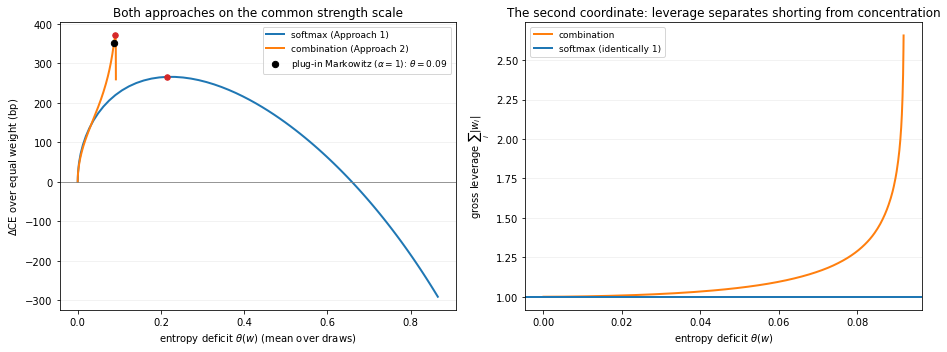

theta at the plug-in Markowitz point (alpha=1): 0.087
theta at alpha* = 1.29: 0.090   |   theta at softmax beta* = 18: 0.215
peak dCE: combination 371 bp vs softmax 266 bp (same draws, same signal)


In [13]:
# ---- both maps on the entropy-deficit axis (baseline case of 3.4 / Exp 3.1) ----
def theta_of(w):
    wt = np.abs(w); wt = wt / wt.sum(axis=1, keepdims=True)
    with np.errstate(divide='ignore', invalid='ignore'):
        H = -np.where(wt > 0, wt * np.log(wt), 0.0).sum(axis=1)
    return 1.0 - H / np.log(N)

th_c = np.array([theta_of(combination_weights(sm, a)).mean() for a in alpha_grid])
th_s = np.array([theta_of(softmax_weights(sm, b)).mean() for b in beta_grid])
CE_sm = np.array([ce_of(softmax_weights(sm, b), Rm) for b in beta_grid])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.plot(th_s, 1e4 * (CE_sm - CE_sm[0]), lw=2, color='tab:blue', label='softmax (Approach 1)')
ax.plot(th_c, dCE_a, lw=2, color='tab:orange', label='combination (Approach 2)')
k1 = np.argmin(np.abs(alpha_grid - 1.0))
ax.scatter([th_c[k1]], [dCE_a[k1]], color='black', zorder=6, s=40,
           label=fr'plug-in Markowitz ($\alpha=1$): $\theta = {th_c[k1]:.2f}$')
ax.scatter([th_c[k]], [dCE_a[k]], color='tab:red', zorder=6, s=30)
ks = int(np.argmax(CE_sm)); ax.scatter([th_s[ks]], [1e4*(CE_sm[ks]-CE_sm[0])], color='tab:red', zorder=6, s=30)
ax.axhline(0, color='grey', lw=0.8)
ax.set_xlabel(r'entropy deficit $\theta(w)$ (mean over draws)')
ax.set_ylabel(r'$\Delta$CE over equal weight (bp)')
ax.set_title('Both approaches on the common strength scale')
ax.grid(axis='y', alpha=0.2)
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(th_c, LEV_a, lw=2, color='tab:orange', label='combination')
ax.axhline(1.0, color='tab:blue', lw=2, label='softmax (identically 1)')
ax.set_xlabel(r'entropy deficit $\theta(w)$')
ax.set_ylabel(r'gross leverage $\sum_i |w_i|$')
ax.set_title(r'The second coordinate: leverage separates shorting from concentration')
ax.grid(axis='y', alpha=0.2)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"theta at the plug-in Markowitz point (alpha=1): {th_c[k1]:.3f}")
print(f"theta at alpha* = {astar:.2f}: {th_c[k]:.3f}   |   theta at softmax beta* = {beta_grid[ks]:.0f}: {th_s[ks]:.3f}")
print(f"peak dCE: combination {dCE_a[k]:.0f} bp vs softmax {1e4*(CE_sm[ks]-CE_sm[0]):.0f} bp (same draws, same signal)")

## Methodological notes

**Estimator.** Every Chapter 3 and Chapter 4 portfolio uses $\mathrm{CE}_{MV}=\mathbb E[P]-(\gamma/2)\operatorname{Var}(P)$. CARA is not mixed into the long-only legs because the shortable legs have infinite population exponential moments under lognormal returns.

**Conditional domain.** The combination map has a mathematical pole at a zero normaliser. Setting-specific 10% masks are computed first and comparisons use their intersection. This makes alternatives paired but defines a conditional estimand. Threshold sensitivity shows that exact basis-point levels and strengths can move materially.

**Tangency language.** $\alpha=1$ exactly reproduces $w_{sig}\propto\Sigma^{-1}s$, called the signal tangency-direction proxy. It is not asserted to be exact Markowitz for simulated simple returns or nonzero risk-free rates.

**Correlation.** Experiment 3.7 first compares the maps under common volatility and then repeats the comparison with heterogeneous volatility. The combination map receives the true covariance matrix in both parts, while softmax continues to use only the drift signal. Under common volatility, equicorrelation rescales the same combination direction. Under unequal volatilities, covariance inversion can also change the portfolio direction and common-shock exposure. The heterogeneous-volatility comparison is highly sensitive to the normaliser-domain threshold.

**Identification and shrinkage.** Log-volatility reliability is an information index, and linear shrinkage of variance is reliability-motivated rather than an exact posterior mean. The three-loading experiment shows weak identification in this calibration, not an exact structural impossibility.

**Common random numbers.** Seeds 42, 4242, 7 and 4343 reproduce the paired market, correlation and volatility objects used throughout. Paired block standard errors accompany conclusions that depend on small performance differences.
